# Exploração do Dataset XJTU-SY e Geração dos Escalogramas CWT

**Projeto:** Diagnóstico de Falhas em Rolamentos Industriais via CWT + Deep Learning  
**Dataset:** Xi'an Jiaotong University & Sumyoung Technology (XJTU-SY Bearing Dataset)  
**Objetivo:** Explorar os sinais de vibração contínuos de **25.6 kHz** do ensaio acelerado de degradação (*run-to-failure*), comparar as condições saudáveis e defeituosas (pistas interna e externa) e gerar o dataset balanceado de escalogramas CWT ($224 \times 224$ pixels) sem vazamento de dados (*data leakage*).

---


## 1. Importação dos Módulos e Parâmetros Globais


In [1]:
import sys
from pathlib import Path

# Adicionar raiz do projeto ao sys.path
BASE_DIR = Path.cwd().parent.parent if Path.cwd().name in ['1_cwru', '2_paderborn', '3_cross_domain', '4_order_tracking', '5_xjtu'] else Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import numpy as np
import matplotlib.pyplot as plt

from src.config import (
    XJTU_RAW_DIR,
    XJTU_PROCESSED_DIR,
    XJTU_CLASSES,
    XJTU_FS,
    XJTU_WINDOW_SIZE,
    XJTU_FREQ_MIN,
    XJTU_FREQ_MAX
)
from src.dataset_xjtu import load_xjtu_csv_file, segment_xjtu_signal, get_xjtu_manifest, extract_xjtu_rpm
from src.generate_dataset_xjtu import compute_xjtu_cwt, process_and_generate_xjtu_dataset


## 2. Resumo das Configurações do Dataset XJTU-SY


In [2]:
print("=" * 60)
print(" CONFIGURAÇÕES DO DATASET XJTU-SY ")
print("=" * 60)
print(f"Taxa de Amostragem (Fs)  : {XJTU_FS:,} Hz (25.6 kHz)")
print(f"Comprimento da Janela     : {XJTU_WINDOW_SIZE} amostras (~{XJTU_WINDOW_SIZE/XJTU_FS*1000:.1f} ms)")
print(f"Faixa de Frequência CWT   : {XJTU_FREQ_MIN} Hz a {XJTU_FREQ_MAX:,} Hz")
print(f"Classes Mapeadas          : {XJTU_CLASSES}")
print("=" * 60)


 CONFIGURAÇÕES DO DATASET XJTU-SY 
Taxa de Amostragem (Fs)  : 25,600 Hz (25.6 kHz)
Comprimento da Janela     : 2048 amostras (~80.0 ms)
Faixa de Frequência CWT   : 10 Hz a 10,000 Hz
Classes Mapeadas          : ['normal', 'inner_race', 'outer_race']


## 3. Carregamento e Comparação dos Sinais de Vibração (25.6 kHz)

Carregamos um sinal de cada condição a partir do manifesto:
* **Normal:** Início do ensaio do rolamento saudável.
* **Pista Interna:** Estágio final com dano severo de pista interna.
* **Pista Externa:** Estágio final com falha por fadiga na pista externa.


In [3]:
manifest = get_xjtu_manifest(max_files_per_class=30)

sample_normal = manifest["normal"][0]
sample_inner  = manifest["inner_race"][-1]
sample_outer  = manifest["outer_race"][-1]

sig_normal = load_xjtu_csv_file(sample_normal, channel=0)
sig_inner  = load_xjtu_csv_file(sample_inner, channel=0)
sig_outer  = load_xjtu_csv_file(sample_outer, channel=0)

print(f"[+] Normal     : {len(sig_normal):,} amostras ({sample_normal.parent.name}/{sample_normal.name}) | RPM: {extract_xjtu_rpm(sample_normal)}")
print(f"[+] Inner Race : {len(sig_inner):,} amostras ({sample_inner.parent.name}/{sample_inner.name}) | RPM: {extract_xjtu_rpm(sample_inner)}")
print(f"[+] Outer Race : {len(sig_outer):,} amostras ({sample_outer.parent.name}/{sample_outer.name}) | RPM: {extract_xjtu_rpm(sample_outer)}")


[+] Normal     : 32,768 amostras (Bearing1_1/1.csv) | RPM: 2100.0
[+] Inner Race : 32,768 amostras (Bearing2_1/491.csv) | RPM: 2250.0
[+] Outer Race : 32,768 amostras (Bearing1_2/161.csv) | RPM: 2100.0


## 4. Visualização dos Sinais no Domínio do Tempo e Escalogramas CWT


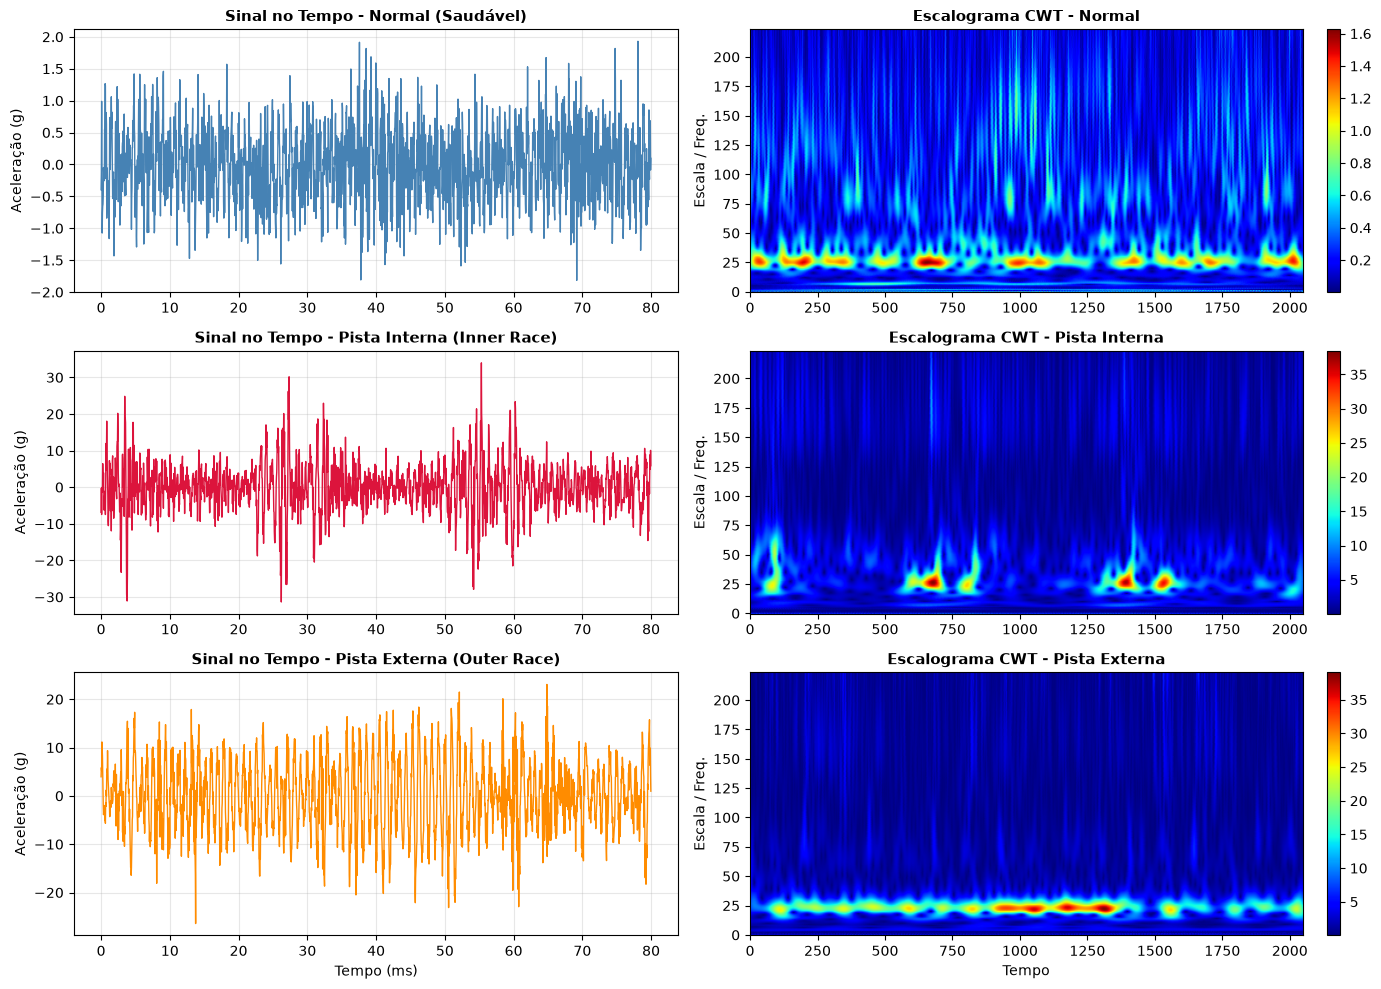

In [4]:
win_normal = segment_xjtu_signal(sig_normal)[0]
win_inner  = segment_xjtu_signal(sig_inner)[0]
win_outer  = segment_xjtu_signal(sig_outer)[0]

cwt_normal = compute_xjtu_cwt(win_normal)
cwt_inner  = compute_xjtu_cwt(win_inner)
cwt_outer  = compute_xjtu_cwt(win_outer)

t = np.arange(len(win_normal)) / XJTU_FS * 1000  # ms

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Linha 1: Normal
axes[0, 0].plot(t, win_normal, color='steelblue', lw=1)
axes[0, 0].set_title("Sinal no Tempo - Normal (Saudável)", fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel("Aceleração (g)")
axes[0, 0].grid(True, alpha=0.3)

im0 = axes[0, 1].imshow(cwt_normal, cmap='jet', aspect='auto', origin='lower')
axes[0, 1].set_title("Escalograma CWT - Normal", fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel("Escala / Freq.")
plt.colorbar(im0, ax=axes[0, 1], fraction=0.046, pad=0.04)

# Linha 2: Pista Interna
axes[1, 0].plot(t, win_inner, color='crimson', lw=1)
axes[1, 0].set_title("Sinal no Tempo - Pista Interna (Inner Race)", fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel("Aceleração (g)")
axes[1, 0].grid(True, alpha=0.3)

im1 = axes[1, 1].imshow(cwt_inner, cmap='jet', aspect='auto', origin='lower')
axes[1, 1].set_title("Escalograma CWT - Pista Interna", fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel("Escala / Freq.")
plt.colorbar(im1, ax=axes[1, 1], fraction=0.046, pad=0.04)

# Linha 3: Pista Externa
axes[2, 0].plot(t, win_outer, color='darkorange', lw=1)
axes[2, 0].set_title("Sinal no Tempo - Pista Externa (Outer Race)", fontsize=11, fontweight='bold')
axes[2, 0].set_xlabel("Tempo (ms)")
axes[2, 0].set_ylabel("Aceleração (g)")
axes[2, 0].grid(True, alpha=0.3)

im2 = axes[2, 1].imshow(cwt_outer, cmap='jet', aspect='auto', origin='lower')
axes[2, 1].set_title("Escalograma CWT - Pista Externa", fontsize=11, fontweight='bold')
axes[2, 1].set_xlabel("Tempo")
axes[2, 1].set_ylabel("Escala / Freq.")
plt.colorbar(im2, ax=axes[2, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## 5. Geração Completa do Dataset de Escalogramas CWT

Execute a célula abaixo para processar e gerar automaticamente os escalogramas CWT divididos em **Treino (70%)**, **Validação (15%)** e **Teste (15%)** em `data/xjtu/processed/`.

> **Nota Anti-Leakage:** A separação é estritamente realizada a nível de **arquivos .csv**, garantindo que janelas do mesmo ensaio não apareçam simultaneamente em treino e teste.


In [5]:
# Execute esta célula para gerar as imagens do dataset XJTU-SY
process_and_generate_xjtu_dataset(max_files_per_class=30)


 GERAÇÃO DO DATASET DE ESCALOGRAMAS CWT — XJTU-SY
    Divisão estrita por ARQUIVOS .csv (Prevenção de Data Leakage)
    Taxa de amostragem: 25600 Hz | Freqs: 10-10000 Hz

[+] Processando classe 'normal' (30 arquivos .csv)...


    ✅ train (normal): 21 arquivos -> 651 imagens geradas


    ✅   val (normal): 4 arquivos -> 124 imagens geradas


    ✅  test (normal): 5 arquivos -> 155 imagens geradas

[+] Processando classe 'inner_race' (30 arquivos .csv)...


    ✅ train (inner_race): 21 arquivos -> 651 imagens geradas


    ✅   val (inner_race): 4 arquivos -> 124 imagens geradas


    ✅  test (inner_race): 5 arquivos -> 155 imagens geradas

[+] Processando classe 'outer_race' (30 arquivos .csv)...


    ✅ train (outer_race): 21 arquivos -> 651 imagens geradas


    ✅   val (outer_race): 4 arquivos -> 124 imagens geradas


    ✅  test (outer_race): 5 arquivos -> 155 imagens geradas

[SUCESSO] Total de 2790 escalogramas gerados e salvos em:
          C:\Users\joaov\Desktop\bearing-fault-diagnosis\bearing-fault-diagnosis-cwt-cnn\data\xjtu\processed
